In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.hamiltonian import Lattice, Hamiltonian
from scripts.self_consistency import bdg_sc

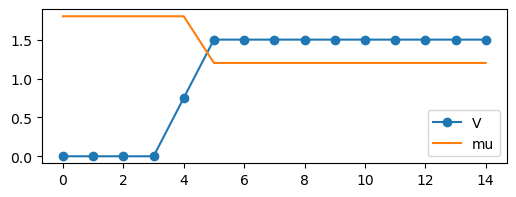

In [2]:
widthN = 5
widthP = 10

X, Y = widthN+widthP, 100
lattice = Lattice(X, Y)
t = 1
T = 1e-6
muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[widthN:] = muN
mu[:widthN] = muP

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthN:] = 0
U[widthN-1] = U[widthN-1]/2
U = None

V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V[:widthN] = 0 
V[widthN-1] = V[widthN]/2
# V = None

V_prime = V0 * np.ones(lattice.X)
V_prime[:widthN] = 0
V_prime[widthN-1] = V_prime[widthN]/2
V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V, F_init=[0.01, -0.01, 0.01j, -0.01j])


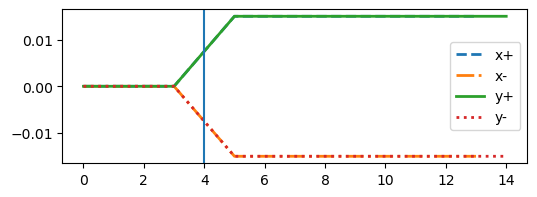

In [4]:
plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(V[:-1]*np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(V[:-1]*np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(V*np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(V*np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [5]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=1000, verbose=True, temperature=T)


d:\X-files\Master Thesis\master-thesis-codebase\scripts\utils.py:59: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp(energy / T) + 1.0)


Iteration 1:
F0:
Absolute error: 0.0018184562862250614
Relative error: 1818456286.2250612
Average old: 0j
Average: (0.0003765612682833308+0j)
F_xplus:
Absolute error: 0.010855290737883338
Relative error: 4108874591.9672976
Average old: (0.007142857142857142+0j)
Average: (0.009190751281899197+0j)
F_xmin:
Absolute error: 0.011357658637787498
Relative error: 3735519387.127429
Average old: (-0.007857142857142856+0j)
Average: (-0.010188608375549475+0j)
F_yplus:
Absolute error: 0.05236863251326663
Relative error: 17366060670.5745
Average old: 0.007333333333333332j
Average: (3.483495583774236e-05+0.020311108695681923j)
F_ymin:
Absolute error: 0.05236863251326663
Relative error: 17366060670.5745
Average old: -0.007333333333333332j
Average: (3.483495583774236e-05-0.020311108695681923j)
Iteration 2:
F0:
Absolute error: 0.0004902739071569791
Relative error: 1.3751568461038468
Average old: (0.0003765612682833308+0j)
Average: (0.0003384741301832716+0j)
F_xplus:
Absolute error: 0.01220229036318716
R

In [6]:
F_yplus = H.F_yplus
F_ymin = H.F_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.F_xplus
F_xmin[1:]  = H.F_xmin

F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2

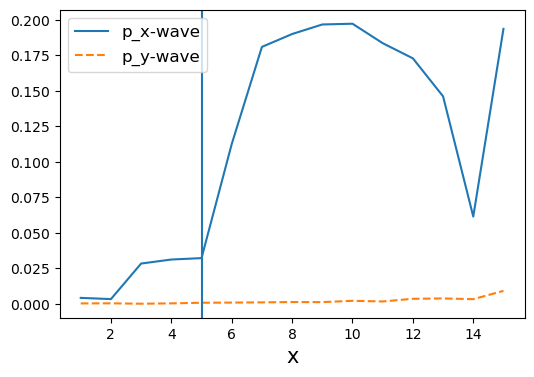

In [7]:
x = np.arange(1, widthN + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(6, 4))

# axs.plot(x, np.real(F_swave), label="s-wave")
# axs.plot(x, np.real(F_dwave), label="d-wave")
axs.plot(x, np.real(F_px2), label="p_x-wave")
axs.plot(x, np.imag(F_py2), "--", label="p_y-wave")
axs.axvline(widthN)
axs.set_xlabel("x", fontsize=15)
# axs.set_xlim(20, 15)
axs.legend(fontsize=12, loc="best")
plt.show()